In [1]:
!pip install lightning transformers torchaudio nnAudio scikit-learn pandas tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.3 MB/s eta 0:00:00


In [2]:
import os
import shutil
import re
import glob
from tqdm import tqdm

INPUT_ROOT = "/kaggle/input/diploma-dataset"
OUTPUT_DIR = "/kaggle/working/final_dataset"

def prepare_final_dataset():
    if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR)
    
    print("Preparing Dataset...")
    
    # ID -> Path to Original
    smp_originals_map = {} 
    
    # SMP (MERT EMBEDDINGS)
    print("\nPreparing SMP Embeddings (from mert_embeddings-00X)...")
    
    smp_pair_folders = glob.glob(f"{INPUT_ROOT}/mert_embeddings-*/mert_embeddings/pair_*", recursive=True)
    
    if not smp_pair_folders:
         smp_pair_folders = glob.glob(f"{INPUT_ROOT}/**/pair_*", recursive=True)
         smp_pair_folders = [p for p in smp_pair_folders if "mert_embeddings" in p]

    print(f"   Found {len(smp_pair_folders)} SMP pairs.")
    
    global_cnt = 1000
    
    for folder in tqdm(smp_pair_folders):
        src_orig = os.path.join(folder, "original.npy")
        src_cov = os.path.join(folder, "cover.npy")
        
        if os.path.exists(src_orig) and os.path.exists(src_cov):
            target = os.path.join(OUTPUT_DIR, f"pair_{global_cnt}")
            os.makedirs(target, exist_ok=True)
            
            shutil.copy2(src_orig, os.path.join(target, "original.npy"))
            shutil.copy2(src_cov, os.path.join(target, "cover.npy"))
            
            folder_name = os.path.basename(folder)
            match = re.search(r'pair_(\d+)', folder_name)
            if match:
                orig_id = match.group(1)
                smp_originals_map[orig_id] = os.path.join(target, "original.npy")
            
            global_cnt += 1

    print(f"SMP Loaded: {global_cnt - 1000} pairs.")

    # HARD POSITIVES (AI COVERS)
    print("\nHard Positives (Covers)...")
    
    hp_folders = [
        f"{INPUT_ROOT}/hard_positives(30)",
        f"{INPUT_ROOT}/hard_positives(49)",
        f"{INPUT_ROOT}/hard_positives(51)"
    ]
    
    ai_cnt = 0
    skipped_ai = 0
    
    for hp_dir in hp_folders:
        if not os.path.exists(hp_dir):
            print(f"Warning: Couldn't find {hp_dir}")
            continue
            
        print(f"   Scanning: {os.path.basename(hp_dir)}")
        cover_files = glob.glob(f"{hp_dir}/*cover*.npy")
        
        for fpath in cover_files:
            fname = os.path.basename(fpath)
            match = re.search(r'pair_(\d+)', fname)
            
            if match:
                pair_id = match.group(1)
                
                if pair_id in smp_originals_map:
                    target = os.path.join(OUTPUT_DIR, f"pair_{ai_cnt}_ai")
                    os.makedirs(target, exist_ok=True)
                    
                    shutil.copy2(fpath, os.path.join(target, "cover.npy"))
                    
                    shutil.copy2(smp_originals_map[pair_id], os.path.join(target, "original.npy"))
                    
                    ai_cnt += 1
                else:
                    skipped_ai += 1
            else:
                pass

    print(f"AI Pairs Created: {ai_cnt}")
    print(f"Skipped AI Covers (No Original found): {skipped_ai}")
    
    total_pairs = len(os.listdir(OUTPUT_DIR))
    print(f"\nTotal pairs created for training: {total_pairs}")
    print(f"Path: {OUTPUT_DIR}")

prepare_final_dataset()

Preparing Dataset...

Preparing SMP Embeddings (from mert_embeddings-00X)...
   Found 150 SMP pairs.


100%|██████████| 150/150 [00:51<00:00,  2.91it/s]


SMP Loaded: 136 pairs.

Hard Positives (Covers)...
   Scanning: hard_positives(30)
   Scanning: hard_positives(49)
   Scanning: hard_positives(51)
AI Pairs Created: 113
Skipped AI Covers (No Original found): 17

Total pairs created for training: 249
Path: /kaggle/working/final_dataset


In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import lightning as L
from transformers import AutoModel, Wav2Vec2FeatureExtractor
from typing import List, Tuple, Dict, Any, Union, Optional
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from numpy.linalg import norm
import torch.optim as optim


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out


class SiameseNet(nn.Module):
    def __init__(self, embedding_dim: int):
        super(SiameseNet, self).__init__()
        self.layer1 = ResidualBlock(3072, 512)
        self.layer2 = ResidualBlock(512, 256)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, embedding_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)
        return x

    def similarity_score(self, sample1, sample2, metric='euclidean'):
        if metric == 'euclidean':
            return torch.nn.functional.pairwise_distance(sample1, sample2)
        elif metric == 'cosine':
            return 1 - torch.nn.functional.cosine_similarity(sample1, sample2)

class PlagiarismDetectionSystem(L.LightningModule):
    def __init__(self, config: Dict):
        super().__init__()
        train_classifier_gap = config["train_classifier_gap"]
        embedding_dim = config["siamese_emb_dim"]

        # Feature extractor trained by triplet loss
        self.siamese_net = SiameseNet(embedding_dim=embedding_dim)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 1),
        )

        # loss functions
        self.criterion_triplet = nn.TripletMarginLoss(margin=2, p=2)
        self.criterion_classification = nn.BCEWithLogitsLoss()

        # how often to train the classification head
        self.train_classifier_gap = train_classifier_gap

        # audio model for inference
        if not hasattr(self, "audio_processor"):
            self.audio_processor = Wav2Vec2FeatureExtractor.from_pretrained("m-a-p/MERT-v1-95M")
        if not hasattr(self, "audio_model"):
            self.audio_model = AutoModel.from_pretrained("m-a-p/MERT-v1-95M", trust_remote_code=True).to(self.device)

    def forward_siamese_net(self, anchors, positives, negatives):
        triplet_embeddings = torch.stack([
                self.siamese_net(anchors),
                self.siamese_net(positives),
                self.siamese_net(negatives)
            ], dim=1
        )
        return triplet_embeddings

    def forward_classifier(self, triplet_embeddings):
        diff_same = torch.abs(triplet_embeddings[:,0] - triplet_embeddings[:,1])
        diff_diff = torch.abs(triplet_embeddings[:,0] - triplet_embeddings[:,2])
        logit_same = self.classifier(diff_same).squeeze()
        logit_diff = self.classifier(diff_diff).squeeze()
        return logit_same, logit_diff

    def training_step(self, batch, batch_idx):
        anchors, positives, negatives = batch
        B = anchors.shape[0]

        # train siamese net
        triplet_embeddings = self.forward_siamese_net(anchors, positives, negatives)
        loss_triplet = self.criterion_triplet(
            triplet_embeddings[:,0], triplet_embeddings[:,1], triplet_embeddings[:,2]
        ) # anchor_embeddings, positive_embeddings, negative_embeddings

        # train classifier
        train_classifier = False
        if self.train_classifier_gap is None:
            train_classifier = True
        elif self.global_step // self.train_classifier_gap == self.train_classifier_gap - 1:
            train_classifier = True

        if train_classifier:
            labels_same = torch.zeros(B).to(triplet_embeddings.device).float()
            labels_diff = torch.ones(B).to(triplet_embeddings.device).float()
            logit_same, logit_diff = self.forward_classifier(triplet_embeddings.detach())
            loss_same = self.criterion_classification(logit_same, labels_same.squeeze())
            loss_diff = self.criterion_classification(logit_diff, labels_diff.squeeze())
            loss_classification = (loss_same + loss_diff) / 2
        else:
            loss_classification = 0

        # final loss
        final_loss = loss_triplet + loss_classification
        self.log("triplet_loss", loss_triplet)
        self.log("classification_loss", loss_classification)
        self.log("total_loss", final_loss)
        return final_loss

    @torch.no_grad()
    def validation_step(self, batch, batch_idx):
        # B, three = batch.shape[0], batch.shape[1]
        # assert three == 3
        anchors, positives, negatives = batch
        B = anchors.shape[0]

        triplet_embeddings = self.forward_siamese_net(anchors, positives, negatives)
        loss_triplet = self.criterion_triplet(
            triplet_embeddings[:,0], triplet_embeddings[:,1], triplet_embeddings[:,2]
        ).cpu().item() # anchor_embeddings, positive_embeddings, negative_embeddings

        labels_same = torch.zeros(B).to(triplet_embeddings.device)
        labels_diff = torch.ones(B).to(triplet_embeddings.device)
        logit_same, logit_diff = self.forward_classifier(triplet_embeddings)
        loss_same = self.criterion_classification(logit_same, labels_same)
        loss_diff = self.criterion_classification(logit_diff, labels_diff)
        loss_classification = ((loss_same + loss_diff) / 2).cpu().item()

        # ">": normal decision (different song, large logit -> TRUE; same song, small logit -> FALSE)
        # If using "<", then it is reverting the decision

        preds_same = torch.sigmoid(logit_same) > 0.5
        preds_diff = torch.sigmoid(logit_diff) > 0.5
        # preds_same = self._inference_step(batch[:,0], batch[:,1]) > 0.5 # same operation
        # preds_diff = self._inference_step(batch[:,0], batch[:,2]) > 0.5
        preds = torch.cat([preds_same, preds_diff])
        labels = torch.cat([labels_same, labels_diff])

        accuracy = (preds.cpu() == labels.cpu()).float().mean()  # Batch accuracy = overall accuracy when batch_size = dataset_size
        accuracy_positive = (preds[:B].cpu() == labels_same.cpu()).float().mean()

        self.log("val_triplet_loss", loss_triplet, prog_bar=True)
        self.log("val_classification_loss", loss_classification, prog_bar=True)
        self.log("val_accuracy", accuracy, prog_bar=True)
        self.log("val_accuracy_positive", accuracy, prog_bar=True)

        return {
            "val_triplet_loss": loss_triplet,
            "val_classification_loss": loss_classification,
        }

    @torch.no_grad()
    def _inference_step(self, sample1:torch.Tensor, sample2:torch.Tensor):
        B1 = sample1.shape[0]
        B2 = sample2.shape[0]
        assert B1 == B2
        B = B1

        out_embs1 = self.siamese_net(sample1)
        out_embs2 = self.siamese_net(sample2)
        diff = torch.abs(out_embs1 - out_embs2)
        logit = self.classifier(diff).squeeze()
        scores = torch.sigmoid(logit)
        return scores

    @torch.no_grad()
    def inference_pairs(
        self,
        waveforms1:Union[List[torch.Tensor], torch.Tensor],
        waveforms2:Union[List[torch.Tensor], torch.Tensor],
    ):
        time_reduce = torch.nn.AvgPool1d(kernel_size=10, stride=10, count_include_pad=False).to(self.device)
        self.eval()

        if type(waveforms1) == list and type(waveforms2) == list:
            assert len(waveforms1) == len(waveforms2)
            waveforms1 = torch.stack(waveforms1).to(self.device)
            waveforms2 = torch.stack(waveforms2).to(self.device)
        elif torch.is_tensor(waveforms1) and torch.is_tensor(waveforms2):
            assert waveforms1.shape[0] == waveforms2.shape[0]
            assert waveforms1.dim() == 2 and waveforms2.dim() == 2
        else:
            assert 0

        # extract MERT features
        hidden_states1 = self.audio_model(waveforms1, output_hidden_states=True).hidden_states
        hidden_states2 = self.audio_model(waveforms2, output_hidden_states=True).hidden_states
        mert_features1 = torch.stack(
            [time_reduce(h.detach()[:, :, :].permute(0,2,1)).permute(0,2,1) for h in hidden_states1[2::3]], dim=1
        )
        mert_features2 = torch.stack(
            [time_reduce(h.detach()[:, :, :].permute(0,2,1)).permute(0,2,1) for h in hidden_states2[2::3]], dim=1
        )
        batch_num, num_layers, num_frames, layer_dim = mert_features1.shape
        mert_features1 = mert_features1.permute(0, 1, 3, 2) # [batch_num, num_layers=4, layer_dim=768, num_frames]
        mert_features2 = mert_features2.permute(0, 1, 3, 2) # [batch_num, num_layers=4, layer_dim=768, num_frames]
        assert mert_features1.shape[1] == 4 and mert_features1.shape[2] == 768
        # mert_features = mert_features.reshape(batch_num, num_layers * layer_dim, num_frames)
        mert_features1 = torch.cat([mert_features1[:,i] for i in range(mert_features1.shape[1])], dim=1)
        mert_features2 = torch.cat([mert_features2[:,i] for i in range(mert_features2.shape[1])], dim=1)

        # get scores for decisions
        # num_features = mert_features.shape[0] // 2
        scores = self._inference_step(mert_features1, mert_features2)

        return 1 - scores # similarity, the higher the more similar (distance smaller)

    def configure_optimizers(self):
        optimizer = optim.Adam(
            list(self.siamese_net.parameters()) + list(self.classifier.parameters()),
            lr=1e-3
        )
        return optimizer



class TripletDataset(Dataset):
    def __init__(self, tracks_dir: str, length_mult=1):
        self.tracks_dir = tracks_dir
        
        self.track_folders = sorted([
            os.path.join(tracks_dir, d) for d in os.listdir(tracks_dir) 
            if os.path.isdir(os.path.join(tracks_dir, d)) and "pair_" in d
        ])
        
        if not self.track_folders:
            raise RuntimeError(f"Δεν βρέθηκαν φάκελοι 'pair_' στο {tracks_dir}")

        self.track_folders = self.track_folders * length_mult
        print(f"Dataset initialized with {len(self.track_folders)} pairs.")

    def __len__(self):
        return len(self.track_folders)

    def _load_and_standardize(self, path):
        try:
            data = np.load(path)
            if data.ndim == 3:
                data = data[np.newaxis, ...]
            if data.ndim == 5:
                data = data.squeeze(0)
            return data
        except Exception as e:
            return None

    def _find_best_match(self, anchor_vec, suspicious_matrix):
        scores = np.dot(suspicious_matrix, anchor_vec)
        norm_anchor = norm(anchor_vec) + 1e-8
        norm_susp = norm(suspicious_matrix, axis=1) + 1e-8
        cosine_sims = scores / (norm_susp * norm_anchor)
        return np.argmax(cosine_sims)

    def __getitem__(self, idx):
        anchor_path = self.track_folders[idx]
        
        anchor_data = self._load_and_standardize(os.path.join(anchor_path, "original.npy"))
        positive_data = self._load_and_standardize(os.path.join(anchor_path, "cover.npy"))

        if anchor_data is None or positive_data is None:
             return self.__getitem__(random.randint(0, len(self) - 1))

        anchor_seg_idx = random.randint(0, anchor_data.shape[0] - 1)
        anchor_sample = anchor_data[anchor_seg_idx] # Shape: (4, Time, 768)

        if positive_data.shape[0] > 1:
            anchor_vec = np.mean(anchor_sample, axis=(0, 1)) 
            
            cover_vecs = np.mean(positive_data, axis=(1, 2))
            
            best_match_idx = self._find_best_match(anchor_vec, cover_vecs)
            positive_sample = positive_data[best_match_idx]
        else:
            positive_sample = positive_data[0]

        while True:
            neg_idx = random.randint(0, len(self.track_folders) - 1)
            if self.track_folders[neg_idx] != anchor_path:
                negative_path_folder = self.track_folders[neg_idx]
                break
        
        # Load Negative
        negative_data = self._load_and_standardize(os.path.join(negative_path_folder, "cover.npy"))
        if negative_data is None: # Fallback to original if cover missing
             negative_data = self._load_and_standardize(os.path.join(negative_path_folder, "original.npy"))
        
        # Random segment from negative
        neg_seg_idx = random.randint(0, negative_data.shape[0] - 1)
        negative_sample = negative_data[neg_seg_idx]

        def prepare(x):
            t = torch.from_numpy(x).float()
            t = t.permute(0, 2, 1)
            t = t.reshape(-1, t.shape[-1])
            return t

        return prepare(anchor_sample), prepare(positive_sample), prepare(negative_sample)

def triplet_collate_fn(batch):
    anchors, positives, negatives = zip(*batch)
    max_len = max([x.shape[-1] for x in anchors + positives + negatives])
    
    def pad(t):
        pad_amt = max_len - t.shape[-1]
        return torch.nn.functional.pad(t, (0, pad_amt)) if pad_amt > 0 else t

    return torch.stack([pad(x) for x in anchors]), \
           torch.stack([pad(x) for x in positives]), \
           torch.stack([pad(x) for x in negatives])

class MERTDataModule(L.LightningDataModule):
    def __init__(self, config, dataset_dir):
        super().__init__()
        self.config = config
        self.dataset_dir = dataset_dir

    def setup(self, stage=None):
        full_dataset = TripletDataset(tracks_dir=self.dataset_dir, length_mult=10)
        
        total_len = len(full_dataset)
        splits = self.config["train_val_test_split"]
        
        train_len = int(splits[0] * total_len)
        val_len = int(splits[1] * total_len)
        test_len = total_len - train_len - val_len
        
        print(f"Splitting Dataset: Train={train_len}, Val={val_len}, Test={test_len}")
        
        self.train_dataset, self.val_dataset, self.test_dataset = random_split(
            full_dataset, [train_len, val_len, test_len], 
            generator=torch.Generator().manual_seed(42)
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.config["train_batch_size"], shuffle=True, collate_fn=triplet_collate_fn, num_workers=self.config["dataloader_num_workers"])

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.config["train_batch_size"], shuffle=False, collate_fn=triplet_collate_fn, num_workers=self.config["dataloader_num_workers"])

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.config["train_batch_size"], shuffle=False, collate_fn=triplet_collate_fn, num_workers=self.config["dataloader_num_workers"])

class PlagiarismDetectionSystemExtended(PlagiarismDetectionSystem):
    def test_step(self, batch, batch_idx):
        results = self.validation_step(batch, batch_idx)
        self.log("test_accuracy", results["val_accuracy_positive"]) # Log using specific key
        return results

print("System Classes Defined")

System Classes Defined


In [13]:
EMBEDDINGS_DIR = "/kaggle/working/final_dataset"

config = {
    "train_val_test_split": [0.8, 0.1, 0.1], # 80% Train, 10% Val, 10% Test
    "train_batch_size": 16,
    "dataloader_num_workers": 2, 
    "max_epochs": 50,
    "check_val_every_n_epoch": 2,
    "train_classifier_gap": None,
    "siamese_emb_dim": 128,
    "log_every_n_steps": 1
}

In [6]:

def main():
    if not os.path.exists(EMBEDDINGS_DIR):
        print(f"Error: {EMBEDDINGS_DIR} not found.")
        return

    data_module = MERTDataModule(config, EMBEDDINGS_DIR)
    
    model = PlagiarismDetectionSystem(config=config)

    checkpoint_callback = ModelCheckpoint(monitor="val_accuracy_positive", mode="max", save_top_k=1, filename="best-acc-{epoch}")
    logger = CSVLogger("logs", name="melodysim_run")

    trainer = L.Trainer(
        max_epochs=config["max_epochs"],
        check_val_every_n_epoch=config["check_val_every_n_epoch"],
        callbacks=[checkpoint_callback],
        accelerator="auto",
        devices=1,
        logger=logger,
        log_every_n_steps=config["log_every_n_steps"]
    )

    print("Starting Training...")
    trainer.fit(model, datamodule=data_module)
    print("Training Finished!")
    

if __name__ == "__main__":
    main()

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_MERT.py: 0.00B [00:00, ?B/s]

...

Trainable params: 102 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 M                                                                                                
Total estimated model params size (MB): 408                                                                        
Modules in train mode: 29                                                                                          
Modules in eval mode: 220                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:534: Found 220 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


Training Finished!


Loading metrics from: /kaggle/working/logs/melodysim_run/version_0/metrics.csv


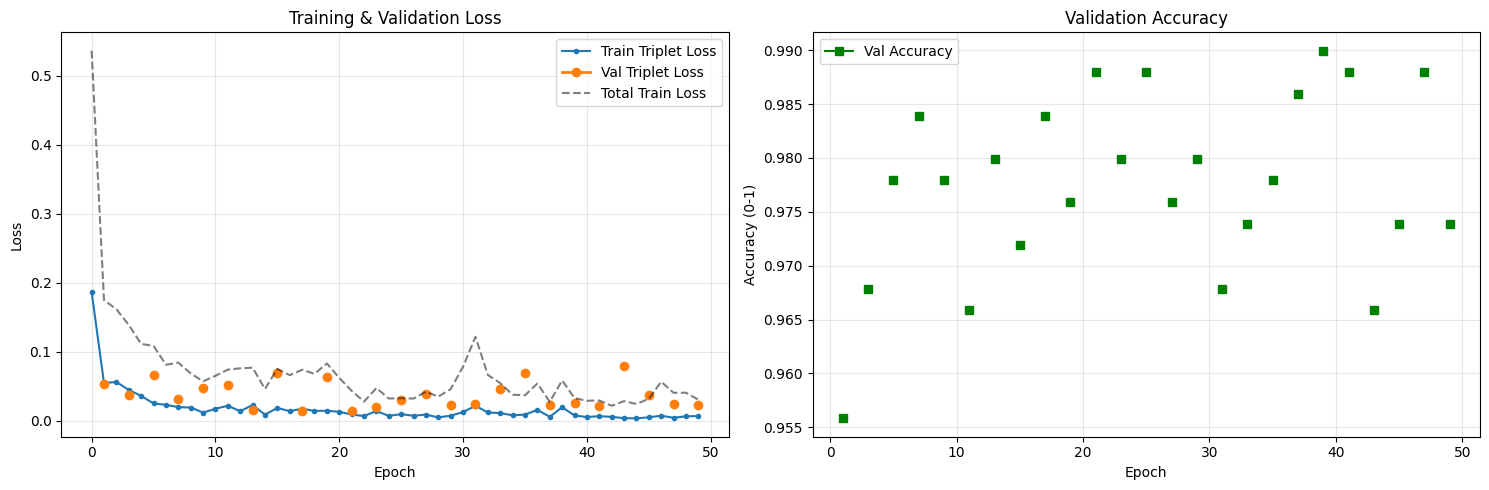

Final Val Loss: 0.0225
Final Val Acc:  97.39%


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_results():
    log_dir = "/kaggle/working/logs/melodysim_run"

    # Last version
    if not os.path.exists(log_dir):
        print("Νο logs found.")
        return

    versions = sorted([d for d in os.listdir(log_dir) if d.startswith("version_")],
                      key=lambda x: int(x.split('_')[1]))

    if not versions:
        print("No versions found.")
        return

    latest_version = versions[-1]
    metrics_path = os.path.join(log_dir, latest_version, "metrics.csv")
    print(f"Loading metrics from: {metrics_path}")

    try:
        metrics = pd.read_csv(metrics_path)

        # Group by epoch to handle multiple steps per epoch
        metrics = metrics.groupby("epoch").mean()

        plt.figure(figsize=(15, 5))

        # Loss Plot
        plt.subplot(1, 2, 1)
        if 'triplet_loss' in metrics.columns:
            plt.plot(metrics.index, metrics['triplet_loss'], label='Train Triplet Loss', marker='.')
        if 'val_triplet_loss' in metrics.columns:
            plt.plot(metrics.index, metrics['val_triplet_loss'], label='Val Triplet Loss', marker='o', linewidth=2)
        if 'total_loss' in metrics.columns:
            plt.plot(metrics.index, metrics['total_loss'], label='Total Train Loss', linestyle='--', color='black', alpha=0.5)

        plt.title('Training & Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # Accuracy Plot
        plt.subplot(1, 2, 2)
        if 'val_accuracy' in metrics.columns:
            plt.plot(metrics.index, metrics['val_accuracy'], label='Val Accuracy', color='green', marker='s')
            plt.title('Validation Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (0-1)')
            plt.grid(True, alpha=0.3)
            plt.legend()
        else:
            plt.text(0.5, 0.5, 'No Accuracy Metric Logged', ha='center')

        plt.tight_layout()
        plt.show()

        print(f"Final Val Loss: {metrics['val_triplet_loss'].iloc[-1]:.4f}" if 'val_triplet_loss' in metrics else "")
        print(f"Final Val Acc:  {metrics['val_accuracy'].iloc[-1]:.2%}" if 'val_accuracy' in metrics else "")

    except Exception as e:
        print(f"Error plotting: {e}")

plot_results()

In [23]:
import torch
import numpy as np
import os
import random
from sklearn import metrics
from tqdm import tqdm
import glob

config = {
    "siamese_emb_dim": 128,
    "train_classifier_gap": None
}

EMBEDDINGS_DIR = "/kaggle/working/final_dataset"

def calibration_evaluation():
    print("Starting Robust Calibration (Concatenation Strategy)...")

    # Load Model    
    checkpoint_path = "/kaggle/input/checkpoint/final_best_model.ckpt" 
    print(f"Loading Model: {checkpoint_path}")

    model = PlagiarismDetectionSystem.load_from_checkpoint(checkpoint_path, config=config)
    model.eval().to("cuda")

    # Load Data
    print("Loading Embeddings...")
    pair_folders = sorted([
        os.path.join(EMBEDDINGS_DIR, d) for d in os.listdir(EMBEDDINGS_DIR) 
        if os.path.isdir(os.path.join(EMBEDDINGS_DIR, d)) and "pair_" in d
    ])

    all_track_data = []
    
    def load_and_concat(path):
        try:
            arr = np.load(path)
            
            if arr.ndim == 3:
                arr = arr[np.newaxis, ...]
            
            if arr.ndim == 5:
                arr = arr.squeeze(0)
                
            
            t = torch.from_numpy(arr).float()
            
            if t.shape[-1] == 768: 
                t = t.permute(0, 1, 3, 2) 
            
            t = t.reshape(t.shape[0], -1, t.shape[-1])
            
            t = t.permute(1, 0, 2).reshape(1, 3072, -1)
            
            return t
        except Exception as e:
            return None

    valid_pairs_indices = []

    for i, folder in enumerate(tqdm(pair_folders)):
        orig_path = os.path.join(folder, "original.npy")
        cover_path = os.path.join(folder, "cover.npy")
        
        if os.path.exists(orig_path) and os.path.exists(cover_path):
            orig = load_and_concat(orig_path)
            cover = load_and_concat(cover_path)
            
            if orig is not None and cover is not None:
                all_track_data.append([orig, cover])
                valid_pairs_indices.append(i)

    num_tracks = len(all_track_data)
    print(f"Loaded {num_tracks} valid pairs (Concatenated).")

    # Evaluation Pairs
    positive_pairs = [(i, 0, i, 1) for i in range(num_tracks)]
    
    negative_pairs = []
    indices = list(range(num_tracks))
    while len(negative_pairs) < len(positive_pairs):
        idx1 = random.choice(indices)
        idx2 = random.choice(indices)
        if idx1 != idx2:
            negative_pairs.append((idx1, 0, idx2, 1))

    all_pairs = positive_pairs + negative_pairs
    all_labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)

    print(f"Evaluating on {len(all_pairs)} pairs...")

    # Inference (One-to-One Comparison)
    preds_scores = []
    
    print("Computing Similarity Scores...")
    with torch.no_grad():
        for t1, v1, t2, v2 in tqdm(all_pairs):
            input1 = all_track_data[t1][v1].to("cuda")
            input2 = all_track_data[t2][v2].to("cuda")
            
            # Inference
            diff_score = model._inference_step(input1, input2)
            sim_score = 1.0 - diff_score.item()
            
            preds_scores.append(sim_score)

    # Tuning Threshold
    print("\nTuning Best Threshold...")
    best_acc = 0
    best_f1 = 0
    best_thresh = 0
    best_preds_binary = []

    thresholds = np.arange(0.1, 0.99, 0.05)

    for t in thresholds:
        curr_preds = [1 if s > t else 0 for s in preds_scores]
        
        acc = metrics.accuracy_score(all_labels, curr_preds)
        f1 = metrics.f1_score(all_labels, curr_preds)
        
        if acc > best_acc:
            best_acc = acc
            best_f1 = f1
            best_thresh = t
            best_preds_binary = curr_preds

    # Final Report
    print("\n" + "="*40)
    print(f"BEST RESULTS")
    print(f"Best Similarity Threshold: {best_thresh:.2f}")
    print("="*40)
    print(metrics.classification_report(all_labels, best_preds_binary, target_names=["Different", "Similar"]))
    print("-" * 40)
    print(f"Max Accuracy: {best_acc:.2%}")
    print(f"Max F1 Score: {best_f1:.4f}")
    print(f"Confusion Matrix:\n{metrics.confusion_matrix(all_labels, best_preds_binary)}")

calibration_evaluation()

Starting Robust Calibration (Concatenation Strategy)...
Loading Model: /kaggle/input/checkpoint/final_best_model.ckpt
Loading Embeddings...


100%|██████████| 249/249 [00:04<00:00, 55.57it/s]


Loaded 136 valid pairs (Concatenated).
Evaluating on 272 pairs...
Computing Similarity Scores...


100%|██████████| 272/272 [00:05<00:00, 51.43it/s]


Tuning Best Threshold...

BEST RESULTS
Best Similarity Threshold: 0.95
              precision    recall  f1-score   support

   Different       0.89      0.81      0.85       136
     Similar       0.82      0.90      0.86       136

    accuracy                           0.85       272
   macro avg       0.86      0.85      0.85       272
weighted avg       0.86      0.85      0.85       272

----------------------------------------
Max Accuracy: 85.29%
Max F1 Score: 0.8592
Confusion Matrix:
[[110  26]
 [ 14 122]]


In [15]:
def run_standard_test():
    print("\nStarting Standard Lightning Testing...")
    
    import glob
    checkpoints = glob.glob(f"{LOGS_DIR}/**/checkpoints/*.ckpt", recursive=True)
    if not checkpoints:
        print("No checkpoints found.")
        return
    best_ckpt = checkpoints[-1]
    
    # Setup Data
    data_module = MERTDataModule(config, EMBEDDINGS_DIR)
    
    #  Extended Class
    class PlagiarismDetectionSystemExtended(PlagiarismDetectionSystem):
        def test_step(self, batch, batch_idx):
            anchors, positives, negatives = batch
            B = anchors.shape[0]

            # Forward pass
            triplet_embeddings = self.forward_siamese_net(anchors, positives, negatives)
            logit_same, logit_diff = self.forward_classifier(triplet_embeddings)

            # Labels (0 = Same, 1 = Different)
            labels_same = torch.zeros(B).to(self.device)
            
            # Predictions
            preds_same = torch.sigmoid(logit_same) > 0.5
            
            # Accuracy on Positive Pairs (Original vs Cover)
            accuracy_positive = (preds_same.cpu() == labels_same.cpu()).float().mean()

            # Log
            self.log("test_accuracy", accuracy_positive, prog_bar=True)
            return accuracy_positive

    # Load Model
    print(f"Loading: {best_ckpt}")
    model = PlagiarismDetectionSystemExtended.load_from_checkpoint(best_ckpt, config=config)
    
    # Test
    trainer = L.Trainer(accelerator="auto", devices=1, logger=False)
    trainer.test(model, datamodule=data_module)

if __name__ == "__main__":
    run_standard_test()


Starting Standard Lightning Testing...
Loading: /kaggle/working/logs/melodysim_run/version_0/checkpoints/best-acc-epoch=39.ckpt


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset initialized with 2490 pairs.
Splitting Dataset: Train=1992, Val=249, Test=249


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │            1.0            │
└───────────────────────────┴───────────────────────────┘

Preparing t-SNE Visualization...
Loading Model: /kaggle/input/checkpoint/final_best_model.ckpt
Dataset initialized with 249 pairs.
Processing 50 pairs...
Computing t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


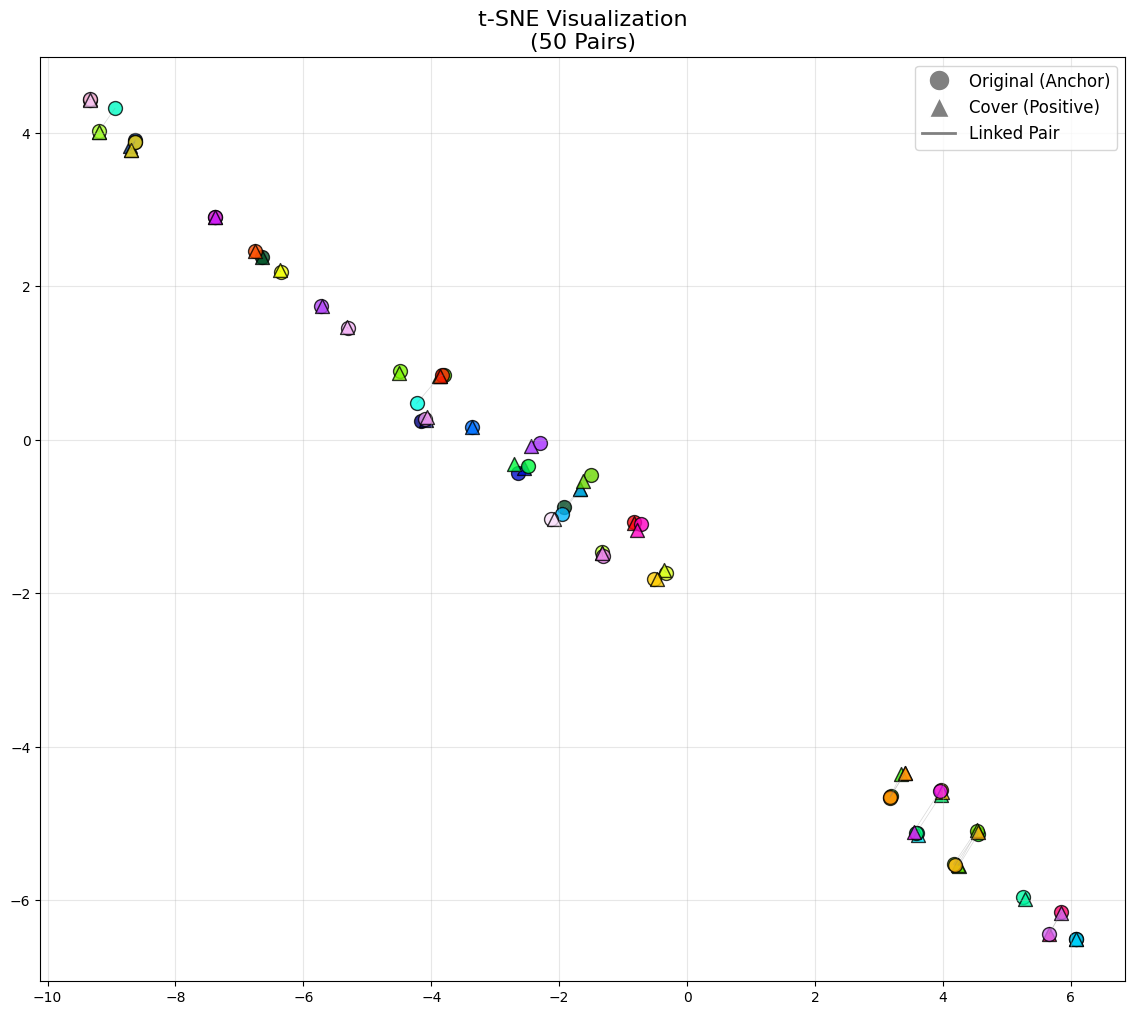

Plot saved as tsne.png


In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import glob
import torch
import os
from matplotlib.lines import Line2D
from torch.utils.data import DataLoader

EMBEDDINGS_DIR = "/kaggle/working/final_dataset"
NUM_PAIRS = 50

system_config = {
    "siamese_emb_dim": 128,
    "train_classifier_gap": 10
}

def visualize_embeddings():
    print("Preparing t-SNE Visualization...")

    # Load Model
    latest_ckpt = "/kaggle/input/checkpoint/final_best_model.ckpt"
    print(f"Loading Model: {latest_ckpt}")

    try:
        model = PlagiarismDetectionSystemExtended.load_from_checkpoint(latest_ckpt, config=system_config)
    except:
        model = PlagiarismDetectionSystem.load_from_checkpoint(latest_ckpt, config=system_config)
        
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # Load Data
    dataset = TripletDataset(EMBEDDINGS_DIR, length_mult=1)
    
    loader = DataLoader(dataset, batch_size=NUM_PAIRS, collate_fn=triplet_collate_fn, shuffle=True)

    print(f"Processing {NUM_PAIRS} pairs...")
    try:
        batch = next(iter(loader))
    except StopIteration:
        print("Dataset empty!")
        return

    anchors, positives, negatives = [b.to(device) for b in batch]

    # Get Embeddings
    with torch.no_grad():
        emb_anchor = model.siamese_net(anchors).cpu().numpy()
        emb_pos = model.siamese_net(positives).cpu().numpy()

    # Prepare Plot Data
    combined = []
    colors = []
    cmap = plt.get_cmap('gist_ncar')

    for i in range(len(anchors)):
        combined.append(emb_anchor[i]) # Even: Original
        combined.append(emb_pos[i])    # Odd: Cover
        
        # Color per pair
        col = cmap(i / NUM_PAIRS)
        colors.append(col)
        colors.append(col)

    combined = np.array(combined)

    # t-SNE
    print("Computing t-SNE...")
    if len(combined) < 50:
        perp = 5 
    else:
        perp = 30
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate=200, n_iter=1000)
    reduced = tsne.fit_transform(combined)

    # Plotting
    plt.figure(figsize=(14, 12))
    
    for i in range(0, len(combined), 2):
        p1 = reduced[i]   # Anchor
        p2 = reduced[i+1] # Positive
        
        # Connection Line
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='gray', linewidth=0.5, alpha=0.3)
        
        # Points
        plt.scatter(p1[0], p1[1], color=colors[i], marker='o', s=100, edgecolors='k', alpha=0.8)
        plt.scatter(p2[0], p2[1], color=colors[i], marker='^', s=100, edgecolors='k', alpha=0.8)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='Original (Anchor)'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=15, label='Cover (Positive)'),
        Line2D([0], [0], color='gray', linewidth=2, label='Linked Pair')
    ]
    
    plt.legend(handles=legend_elements, loc='best', fontsize=12)
    plt.title(f"t-SNE Visualization\n({NUM_PAIRS} Pairs)", fontsize=16)
    plt.grid(True, alpha=0.3)
    
    plt.savefig("/kaggle/working/tsne.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot saved as tsne.png")

visualize_embeddings()

Checking Distance Matrix...
Loading: /kaggle/input/checkpoint/final_best_model.ckpt
Dataset initialized with 249 pairs.

Distance Matrix:
            Cover 1     Cover 2     Cover 3     Cover 4     Cover 5  \
Orig 1     2.440000   55.959999  142.779999  133.919998   19.530001   
Orig 2    56.889999    0.620000   87.080002  189.669998   74.830002   
Orig 3   144.119995   87.220001    0.670000  276.890015  161.639999   
Orig 4   133.330002  190.250000  277.149994    0.830000  115.989998   
Orig 5    19.440001   75.129997  161.639999  115.269997    0.760000   
Orig 6    31.200001   27.070000  113.269997  163.490005   48.200001   
Orig 7   257.290009  314.209991  401.029999  124.550003  239.649994   
Orig 8    19.549999   38.009998  124.669998  152.029999   36.930000   
Orig 9    20.160000   76.839996  163.729996  112.959999    6.900000   
Orig 10  345.549988  402.489990  489.380005  212.750000  328.070007   

            Cover 6     Cover 7     Cover 8     Cover 9    Cover 10  
Orig 1    

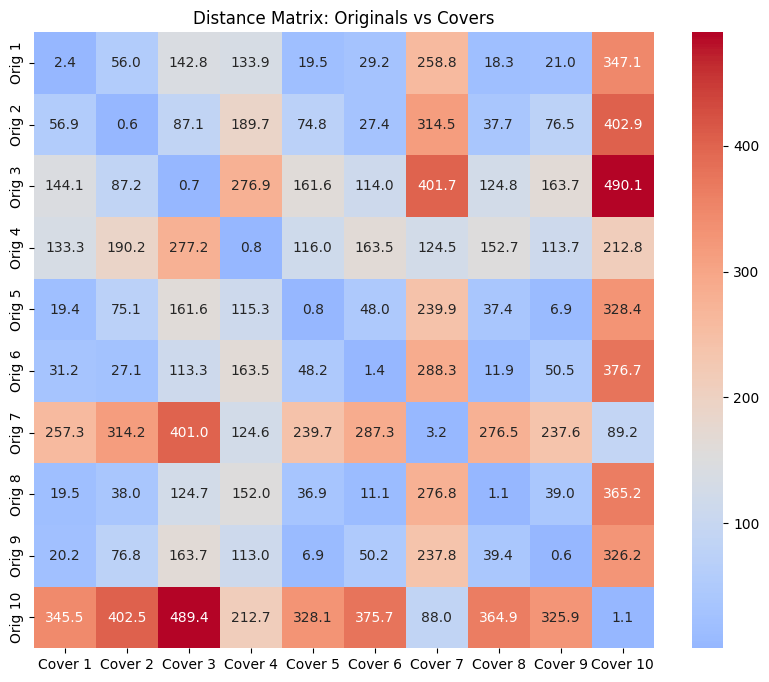

In [16]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
from torch.utils.data import DataLoader

def check_matrix():
    print("Checking Distance Matrix...")

    latest_ckpt = "/kaggle/input/checkpoint/final_best_model.ckpt"
    print(f"Loading: {latest_ckpt}")

    model = PlagiarismDetectionSystem.load_from_checkpoint(latest_ckpt, config=system_config)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    dataset = TripletDataset(EMBEDDINGS_DIR, length_mult=1)
    loader = DataLoader(dataset, batch_size=10, collate_fn=triplet_collate_fn, shuffle=True)

    batch = next(iter(loader))
    anchors, positives, _ = [b.to(device) for b in batch]

    with torch.no_grad():
        emb_anchor = model.siamese_net(anchors)
        emb_pos = model.siamese_net(positives)
        dists = torch.cdist(emb_anchor, emb_pos).cpu().numpy()

    df = pd.DataFrame(dists,
                      index=[f"Orig {i+1}" for i in range(10)],
                      columns=[f"Cover {i+1}" for i in range(10)])

    print("\nDistance Matrix:")
    print(df.round(2))

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt=".1f", cmap="coolwarm", center=np.mean(dists))
    plt.title("Distance Matrix: Originals vs Covers")
    plt.savefig("thesis_heatmap.png", dpi=300)
    plt.show()

check_matrix()

In [7]:
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache cleared.")

%reset -f

import gc

gc.collect()
print("Python garbage collector run. RAM should be clearer.")

✅ GPU cache cleared.
✅ Python garbage collector run. RAM should be clearer.
